# Data Preprocessing Part

In [375]:
import pandas as pd

# Read raw data from github repo 
df=pd.read_csv("https://raw.githubusercontent.com/Alex-Mak-MCW/Deposit_Subcriptions_Predictions_Project/main/Data/input.csv", sep=";")

print(df.shape) # returned (45211, 17), success

(45211, 17)


In [376]:
# Data Cleaning: handled 

# identify null data
print("Number of null values in the dataset:\n{0}".format(df.isnull().sum())) # There are no null values

# identify duplciate data
print("\nNumber of duplicate data in the dataset:\n{0}".format(df.isnull().sum())) # There are no duplicate values

Number of null values in the dataset:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Number of duplicate data in the dataset:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [377]:
# Data Transformation: 
from sklearn.preprocessing import LabelEncoder

data=df.copy()

# 1. Encode binary variables 
# Initialize LabelEncoder for binary encoding
label_encoder = LabelEncoder()

# 1.1 encode binary predictors
data['default']=label_encoder.fit_transform(data['default'])
data['housing']=label_encoder.fit_transform(data['housing'])
data['loan']=label_encoder.fit_transform(data['loan'])

# 1.2 encode binary target variable (y)
data['y']=label_encoder.fit_transform(data['y'])

# 2. encoding categorical data with multiple class (job, marital, education, contact, month, poutcome)

# 2.1 month: since months are just the abbreviations (short forms of the month) --> encode strings to months numerically  
data['month']=label_encoder.fit_transform(data['month'])+1

# 2.2 education (unknown exists): map values with setted values where higher educations are mapped with higher values
data['education']=data['education'].map({"unknown": 0, "primary": 1, "secondary": 2, "tertiary": 3})

# 2.3 poutcome (unknown exists): map values with setted values where failure is 0, success is 1, unknown and otheras 0.5
data['poutcome']=data['poutcome'].map({"failure": 0, "success": 1, "unknown": 0.5, "other": 0.5})

# I decided to leave the rest untouched because tree-based methods can handle categorical data pretty well already.
# Hence I did not handle: contact, marital, and job (as of now)


# 3. replace unknown with meaningful value (for contact, education, job)

# 3.1 job, try to categorize retired and student out first based on age, then see what to do

# everyone under 22 are already students, so transform elders
data.loc[data['age'] >66, 'job'] = data.loc[data['age'] >66, 'job'].replace('unknown', 'retired')
# print(data['job'].value_counts()) # 278 unknown values now, 10 unknown ones are removed

# transform adults (6% still do it?)
# print(data['job'].value_counts(normalize=True)) # 278 unknown values now

# 3.2: contact, replace with mode--> cellular
# cellular returns 65%, unknown returns 29%, telephone returns 6%
data['contact']=data['contact'].replace("unknown", "cellular")

# 3.3 education, replace with mode--> 2 
# 0: 4%, 1: 15%, 2: 51%, 3: 29%
data['education']=data['education'].replace(0, 2)

# EDA Part

## For examining and understanding the structure, patterns, and relationships within a dataset.

### todo-list:

* provide descriptive statistics (DONE)

* univariate: (DONE)
1. outlier detection through boxplots for continuous data
2. frequency analysis through barplot for discrete data

* outlier and unknown removal--> (DONE)

* multivariate: pairwise scaterplot(predictor vs y) to see trends, correlation analysis to check multicolinarity (heatmaps)

* feature importance model--> 

* No standarizations and multicolinearity

* write conclusions

In [378]:
# Descriptive/ Summary statistics for continuous data

# exclude default, house, loan, poutcome, y (becuase they are categorical variables)
summary=data.describe().drop(['default', 'housing', 'loan', 'poutcome', 'y'], axis=1).style.set_caption('Summary Statistics for Continuous Data').format(precision=2).background_gradient(cmap='Blues')
display(summary)

,age,education,balance,day,month,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,2.14,1362.27,15.81,6.52,258.16,2.76,40.20,0.58
std,10.62,0.65,3044.77,8.32,3.01,257.53,3.10,100.13,2.30
min,18.00,1.00,-8019.00,1.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,2.00,72.00,8.00,4.00,103.00,1.00,-1.00,0.00
50%,39.00,2.00,448.00,16.00,7.00,180.00,2.00,-1.00,0.00
75%,48.00,3.00,1428.00,21.00,9.00,319.00,3.00,-1.00,0.00
max,95.00,3.00,102127.00,31.00,12.00,4918.00,63.00,871.00,275.00


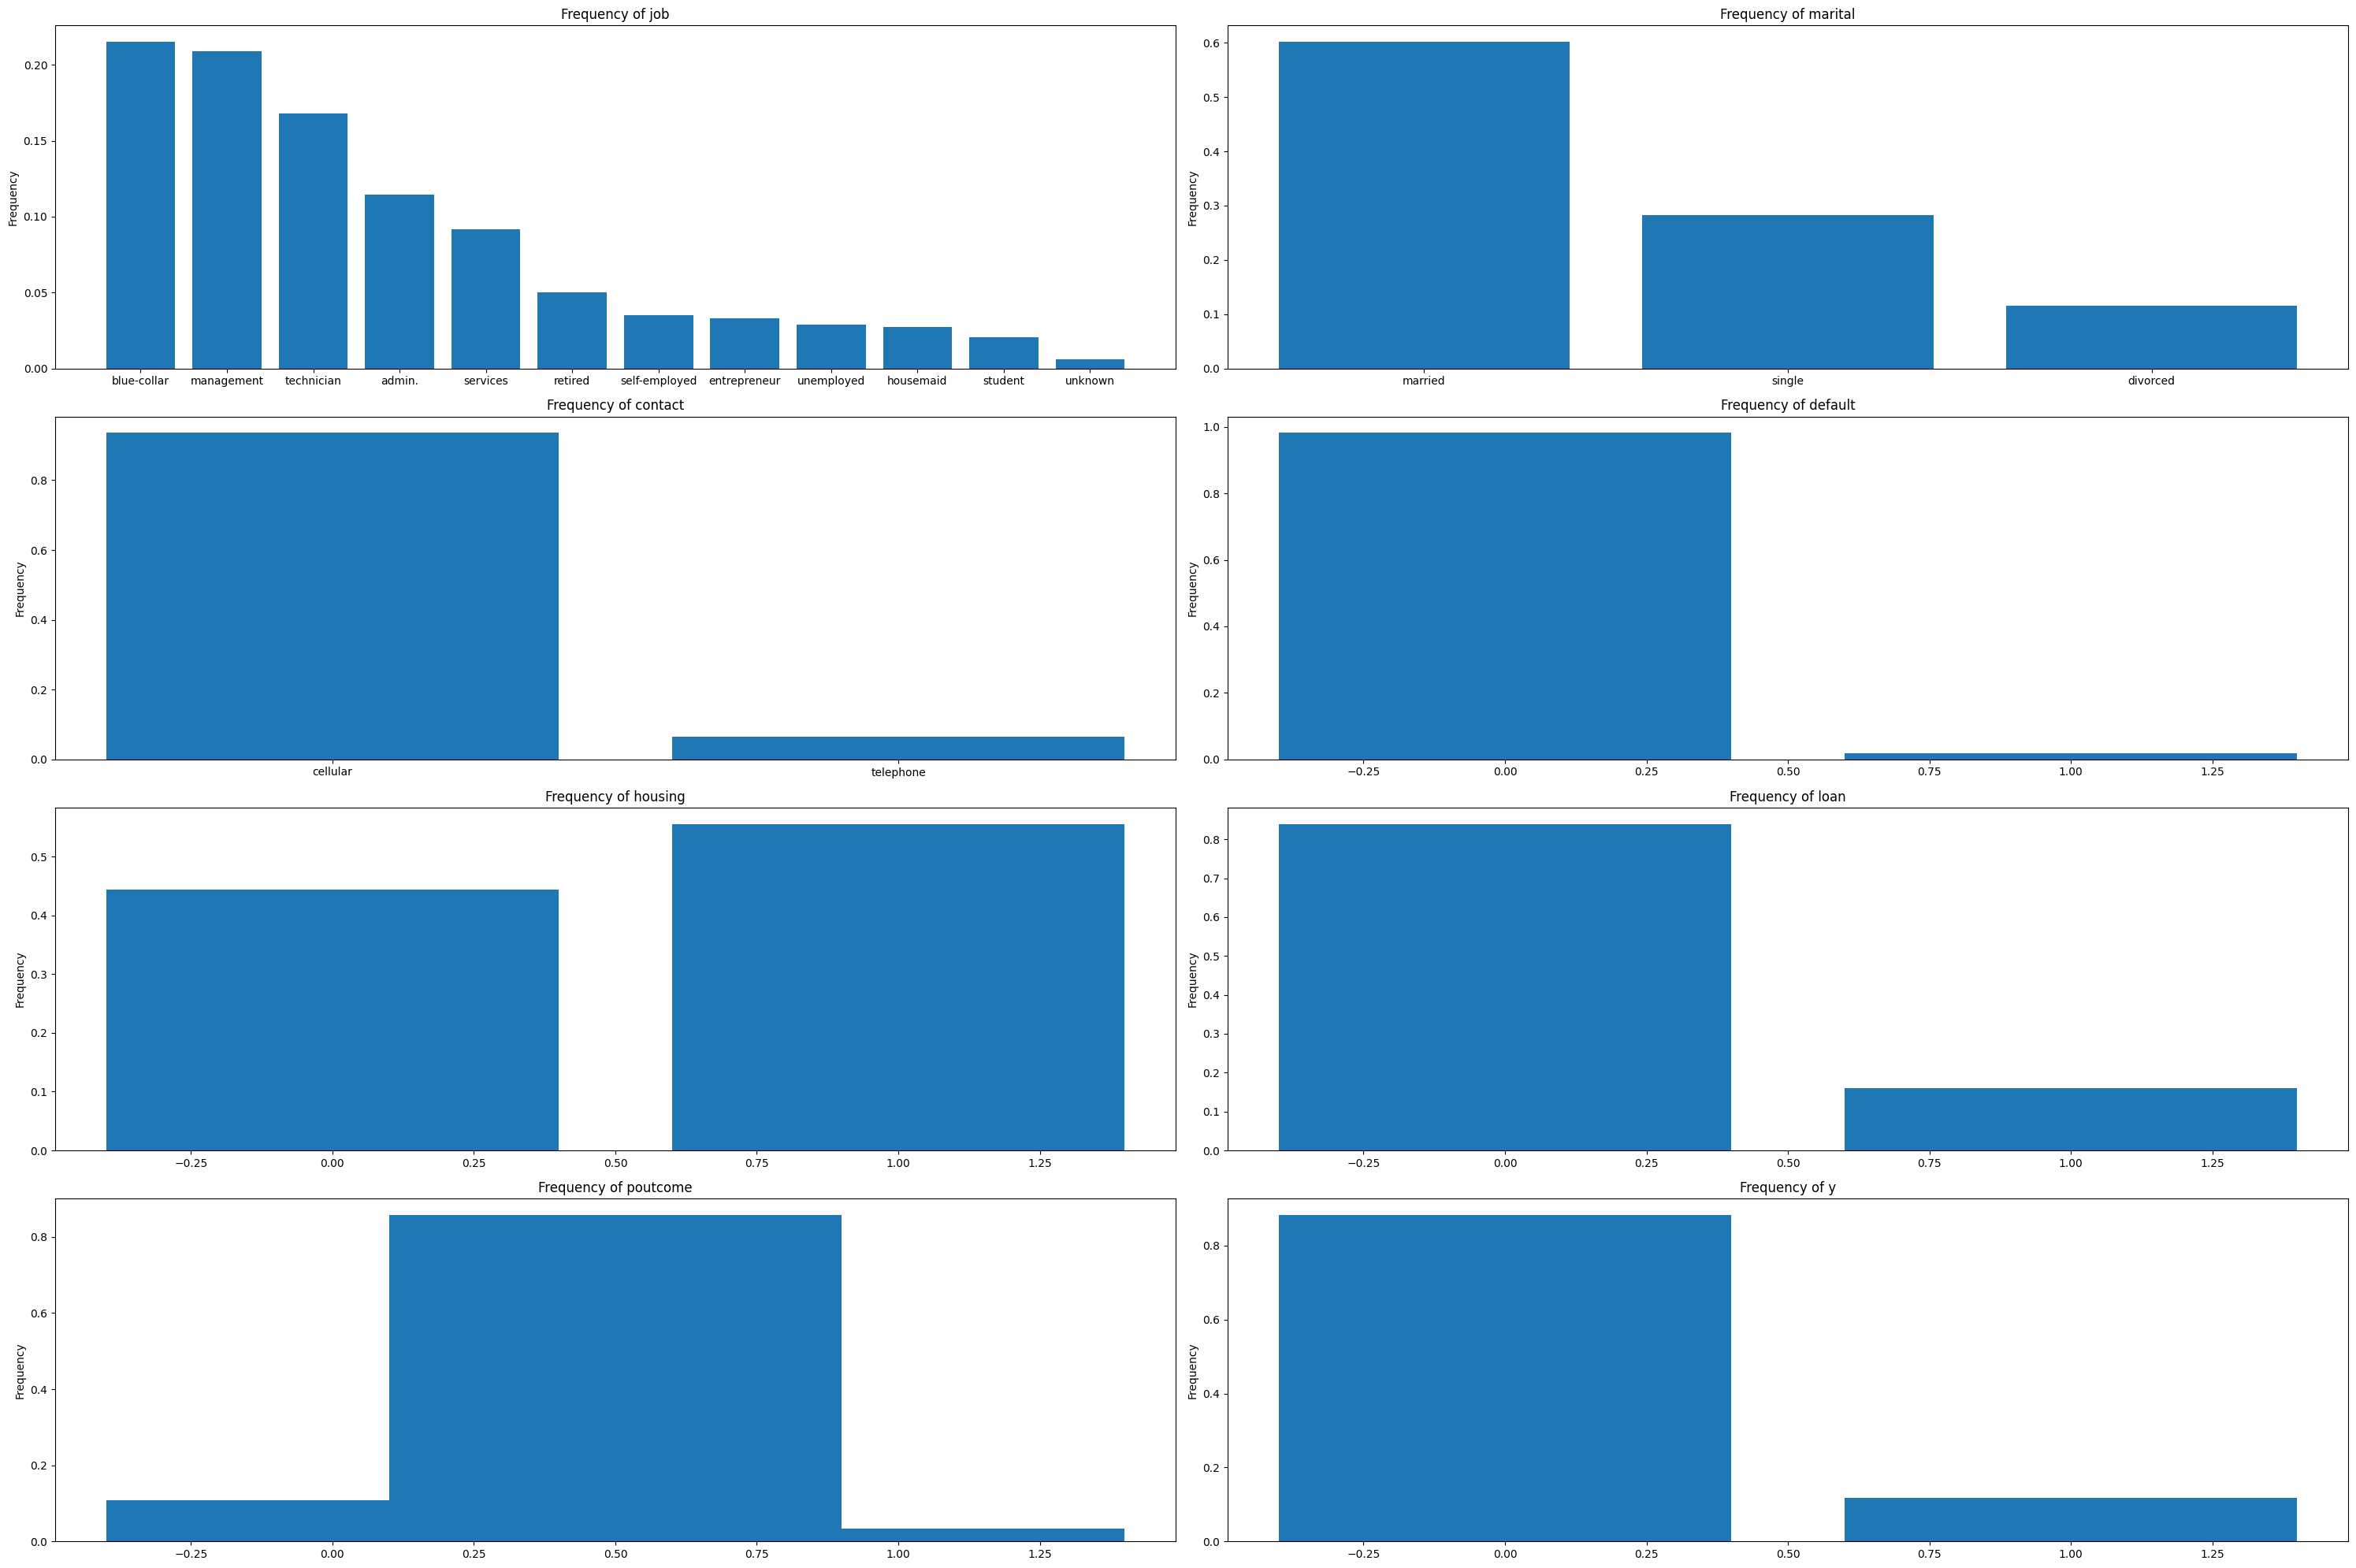

In [379]:
# frequency analysis for categorical variable and encoded numerical variables:
import matplotlib.pyplot as plt

# categorical variables (job, marital, contact) and encoded numerical variables ('default', 'housing', 'loan', 'poutcome', 'y')
# categorical_columns = data.select_dtypes(include=['object']) # returned(job, marital, contact) 

# Calculate frequencies of each category for all variables
category_counts = {}
target_list=['job', 'marital', 'contact', 'default', 'housing', 'loan', 'poutcome', 'y']
for col in target_list:
    # (NOTE) if you wanna see counts
    # category_counts[col] = data[col].value_counts()
    
    # (NOTE) if you wanna see percentages
    category_counts[col] = data[col].value_counts(normalize=True)

# subplots
fig, axes = plt.subplots(4, 2, figsize=(30, 20))

# Plot frequencies for each variable
for i, column in enumerate(target_list):
    row = i // 2
    col = i % 2
    if row < 4 and col < 2:
        axes[row,col].bar(category_counts[column].index, category_counts[column].values)
        axes[row,col].set_title(f'Frequency of {column}')
        axes[row,col].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

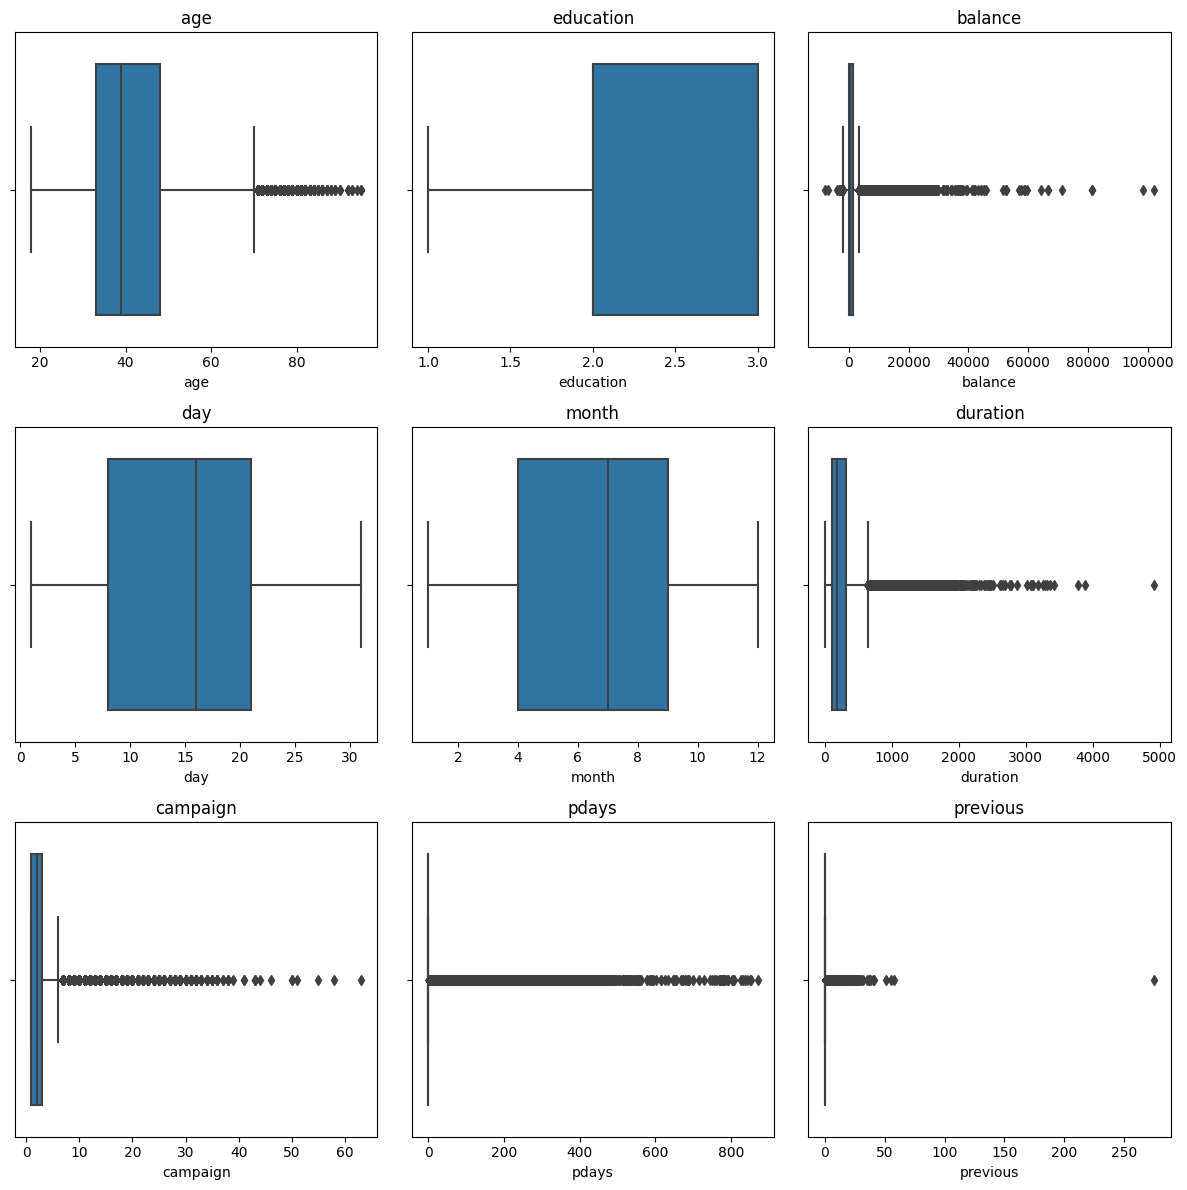

In [380]:
# Univariate analysis:
import matplotlib.pyplot as plt
import seaborn as sns

# outlier detection
# age, education, default, balance, housing, loan, day, month, duration, campaign, pdays, previous, poutcome, y
num_rows = 3
num_cols = 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 12))

# exclude poutcome and y
# Plot each numeric column's box plot
for i, column in enumerate(data.select_dtypes(include=['number']).drop(['default', 'housing', 'loan', 'poutcome', 'y'],axis=1).columns):
    row = i // num_cols
    col = i % num_cols
    if row < num_rows and col < num_cols:
        sns.boxplot(x=data[column], ax=axes[row, col])
        axes[row, col].set_title(column)

# Adjust layout
plt.tight_layout()
plt.show()

# outlier detection analysis:

* day, and month are good (approximately normal)
* education is also ok (but left skewed)
<br><br>
* age: there is a bunch of elders who become outliers, but I don't think we should remove them nor scaled them (why normalize age?).
* balance, duration, campaign: right skewed with bunch of outliers and some extreme datapoints (just remove some extreme ones)
* pdays: bunch of outliers, but I don't suggest removing (there is no point unless we take out all of them XD)

# handling unknowns:

* unknown existed in job, education, contact, poutcome--> now only job
* 
* print(data['job'].value_counts(normalize=True)) # 278 unknowns, or 0.006149 aka 0.6%


* not going to handle it becuase it's hard to assign jobs to adult, need more information


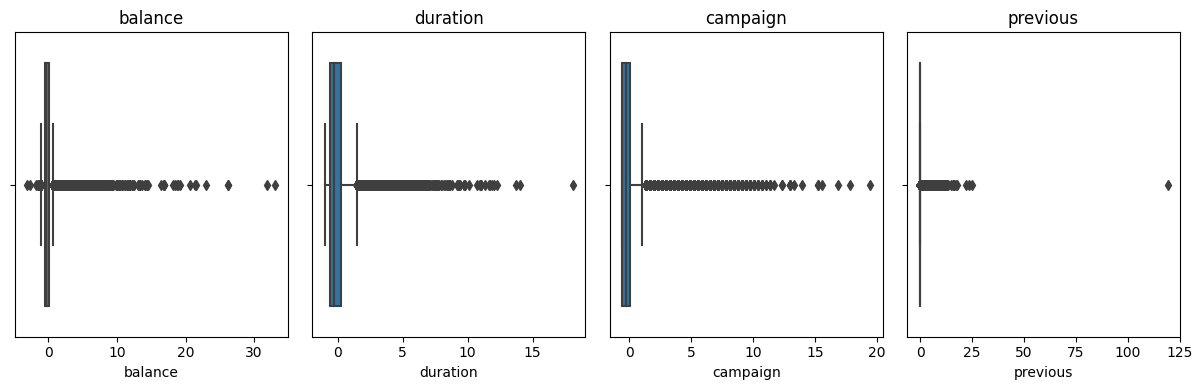

In [381]:
# Outlier removal - I will probably only remove only a few extreme ones

# observe true outliers by standardize first to see their relative positions
# fail safe
test=data.copy()

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
test['balance']=scaler.fit_transform(test[['balance']])
test['duration']=scaler.fit_transform(test[['duration']])
test['campaign']=scaler.fit_transform(test[['campaign']])
test['previous']=scaler.fit_transform(test[['previous']])

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
test_list=['balance', 'duration', 'campaign', 'previous']

# Plot each numeric column's box plot 
for i, column in enumerate(test_list):
    sns.boxplot(x=test[column], ax=axes[i])
    axes[i].set_title(column)

# Adjust layout
plt.tight_layout()
plt.show()

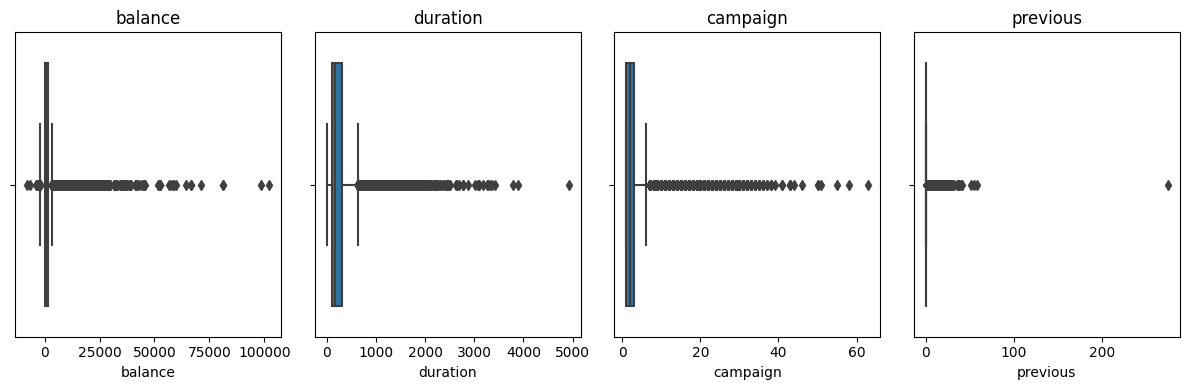

(45211, 17)
(45200, 17)


In [382]:
# ACTUAL REMOVE
# relatively conservative identified from previous scale (plan to remove 11)
# new: plan to remove largest previous, largest duration, largest 2 balances,  not going to remove campaign (hard to identify)

# observe in full data

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
test_list=['balance', 'duration', 'campaign', 'previous']

# Plot each numeric column's box plot
for i, column in enumerate(test_list):
    sns.boxplot(x=data[column], ax=axes[i])
    axes[i].set_title(column)

# Adjust layout
plt.tight_layout()
plt.show()

# actual removing
print(data.shape) # returned (45211, 17)
adjusted_data=data.loc[~((data['previous']>45)| (data['balance']> 80000)| (data['duration']> 3600))]
print(adjusted_data.shape) # returned (45200, 17)

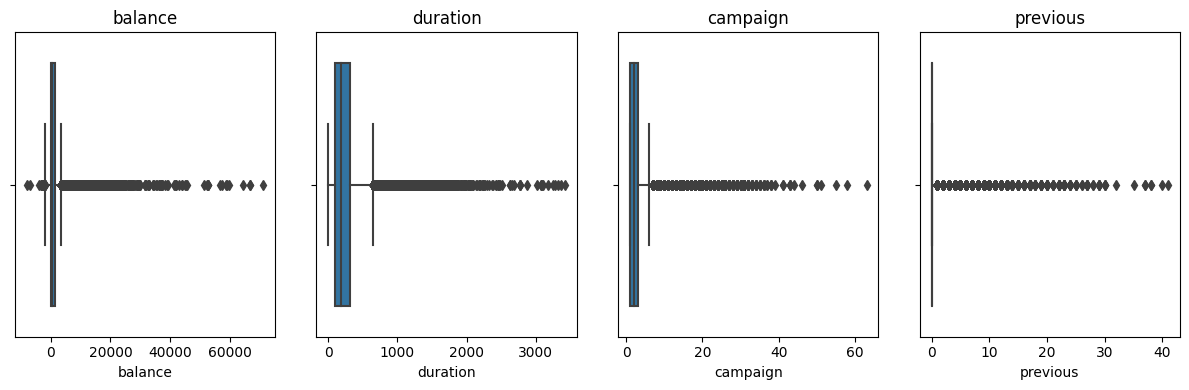

In [383]:
# plot once more to check (confirmed)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
test_list=['balance', 'duration', 'campaign', 'previous']

# Plot each numeric column's box plot
for i, column in enumerate(test_list):
    sns.boxplot(x=adjusted_data[column], ax=axes[i])
    axes[i].set_title(column)

# Adjust layout
plt.tight_layout()
plt.show()

# Concluion for outlier removal:
* removed 11 datapoints, returned (45200, 17)
* can be addjusted later for more aggressive/ conservative

# Data Normalization/ Standardization 

* Conclusion: since we plan to use tree-based method which are insensitive to the magnitude of variables. I don't suggest to do so

In [384]:
# # Multivariate analysis- print pairwise scatterplot for each x to y
# # Warning: takes a long time to run (~ 10 mins)
# import seaborn as sns
# sns.pairplot(adjusted_data, hue="y")

# Observation:

* rarely any linear relationships (which is expected to be honest).
* Hard to observe any obvious patterns (aside from a few on the upper triangle)
* I would say insignificant to no mutlicolienarity.
* No distinct outliers after outlier removal 

In [385]:
# encode all data first for fitting

adjusted_data.select_dtypes(include=['object']).columns

# encode job, marital, and contact with one-hot encoding
# adjusted_data['job'] # HARD AF

# let's try on contact first
test=adjusted_data.copy()

encoded_test=pd.get_dummies(test, columns=['contact', 'marital', 'job'])
encoded_test

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,58,3,0,2143,1,0,5,9,261,1,...,0,0,1,0,0,0,0,0,0,0
1,44,2,0,29,1,0,5,9,151,1,...,0,0,0,0,0,0,0,1,0,0
2,33,2,0,2,1,1,5,9,76,1,...,1,0,0,0,0,0,0,0,0,0
3,47,2,0,1506,1,0,5,9,92,1,...,0,0,0,0,0,0,0,0,0,0
4,33,2,0,1,0,0,5,9,198,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,3,0,825,0,0,17,10,977,3,...,0,0,0,0,0,0,0,1,0,0
45207,71,1,0,1729,0,0,17,10,456,2,...,0,0,0,1,0,0,0,0,0,0
45208,72,2,0,5715,0,0,17,10,1127,5,...,0,0,0,1,0,0,0,0,0,0
45209,57,2,0,668,0,0,17,10,508,4,...,0,0,0,0,0,0,0,0,0,0


In [386]:
# reassign back once encoded - for safety reasons
adjusted_data=encoded_test

In [404]:
# Feature engineering:

# Build a new feature (numDays): to combine month and day to get number of days, 

# Calculate number of days in a year using lambda function
adjusted_data['days_in_year'] = adjusted_data.apply(lambda row: 366 if row['month'] == 2 and row['day'] == 29 else 365 
                                        if row['month'] == 2 else sum([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31][:int(row['month'])]) + int(row['day']), axis=1)

/var/folders/vz/8f0dlrxd14g849p0gddrr1c00000gn/T/ipykernel_84287/1003663180.py:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  testrf.fit(x, y)


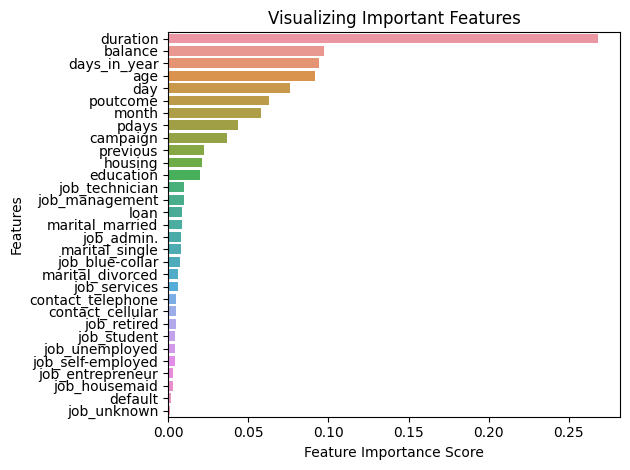

In [406]:
# feature importance model (investigate relationship for clasification problems)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# identify x and y first
x=adjusted_data.loc[:, adjusted_data.columns !='y']
y=adjusted_data.loc[:, adjusted_data.columns =='y']

# fitting the entire data just to observe fetaure importnce
testrf=RandomForestClassifier()
testrf.fit(x, y)
importances=testrf.feature_importances_

# Plot out the features' importance using a barplot
feature_imp = pd.Series(importances, index=x.columns).sort_values(ascending=False)
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.tight_layout() 


In [407]:
# export to csv for prepared data
print(adjusted_data.shape) # returned (45200, 31)
adjusted_data.to_csv("processedInput.csv", header=True, index=False) # success

(45200, 32)


In [583]:
# try to split the data once read

processed_data=pd.read_csv("https://raw.githubusercontent.com/Alex-Mak-MCW/Deposit_Subcriptions_Predictions_Project/main/Data/processedInput.csv", sep=",")
# print(processed_data.shape) #(45200, 31)--> good

# identify x and y first
x=processed_data.loc[:, processed_data.columns !='y']
y=processed_data.loc[:, processed_data.columns =='y']

# The rest will be handled very soon :) May not be me though XD
# print(processed_data.describe())

In [584]:
# Implement DT:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# 1. data splitting into train-test-validation split (80-10-10)
# first split train as 80%, rest 20%
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.2)

# split the 20% by half (10% test, 10% validation)
X_val, X_test, y_val, y_test=train_test_split(X_test,y_test,test_size=0.5)


# 2. train and fit a decision tree model using the training data
DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)

DecisionTreeClassifier()

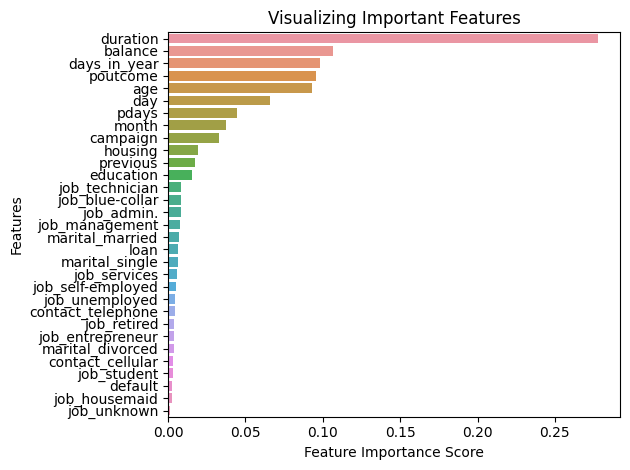

In [585]:
# 3. model analysis: interpret feature importance

from sklearn.metrics import accuracy_score

# 3.1 make predictions on y using training data's x
DT_train_pred=DT.predict(X_test)

# 3.2 measure importance of each features to further improve the model
DT_feature_imp = pd.Series(DT.feature_importances_, index=X_train.columns).sort_values(ascending=False)
# print("Accuracy: {}".format(metrics.accuracy_score(y_test, DT_train_pred))) # 0.8752212389380531

# Plot out the features' importance using a barplot
sns.barplot(x=DT_feature_imp, y=DT_feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.tight_layout() 

# The ones I regard as important are the ones without jobs and marriage status (keeping everything till loan)

In [586]:
# 4. Variable selection & use the vaildiation data to perform hyperparameter tuning
from sklearn.metrics import accuracy_score

new_cols=['duration', 'balance', 'days_in_year', 'age', 'poutcome', 'day', 'pdays', 'month', 'campaign', 'education', 'previous', 'housing','loan']

# Removing less important features on training, testing, and validtion  (13 columns left)
DT_X_train = X_train.loc[:, new_cols]   # (36160, 13)
DT_X_test = X_test.loc[:, new_cols]     # (4520, 13)
DT_X_val = X_val.loc[:, new_cols]       # (4520, 13)

# 4.1: Define the hyperparameters to tune
# Grid search CV (cross validation) to find the best hyperparameters for tuning
DT_param_grid = {
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [3, 6, 9],
    'max_leaf_nodes': [3, 6, 9],
    'criterion': ['gini', 'entropy', 'log_loss'],
    # 'splitter': ['best', 'random'],
    'min_samples_split' : [2, 3, 6, 9],
    'min_samples_leaf' : [1, 3, 6, 9],
}

# 4.2: Perform grid search cross-validation (5 fold CV)
DT_grid_search = GridSearchCV(DT, DT_param_grid, cv=5, scoring='accuracy')
DT_grid_search.fit(DT_X_val, y_val)

# 4.3: Get the best hyperparameters
DT_best_params = DT_grid_search.best_params_
# print(DT_best_params) # success

# 5. refit the model with the best parameter
DT_best_model = DecisionTreeClassifier(**DT_best_params)

# reshaped y to ensure it fits
DT_best_model.fit(DT_X_train, y_train.values.reshape(1,-1)[0])


# 6. Make predictions of the actual model and obtain accuracy
DT_y_pred=DT_best_model.predict(DT_X_test)

# Accuracy Score, they are around 89-91%
print("Tuned Accuracy: {}".format(accuracy_score(y_test, DT_y_pred)))

Tuned Accuracy: 0.8973451327433628


In [599]:
# 4. AUTOMATED Variable selection & use the vaildiation data to perform hyperparameter tuning
# tuning pipeline: 
# Warning: ALMOST 9 mins to run

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV

# 4.1 Define Pipeline
DT_pipeline = Pipeline([
    # Variable Selection and Hyperparameter Tuning
    ('feature_selection', SelectFromModel(DecisionTreeClassifier())),
    ('classifier', DT)
])

# 4.2 define param grid for pipeline only
DT_pipeline_param_grid= {
    'feature_selection__estimator__criterion': ['gini', 'entropy'],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__max_depth': [3, 6, 9],
    'classifier__max_leaf_nodes': [3, 6, 9],
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__min_samples_split' : [2, 3, 6, 9],
    'classifier__min_samples_leaf' : [1, 3, 6, 9],
}

# 4.3 Perform Grid Search CV
DT_grid_search = GridSearchCV(DT_pipeline, DT_pipeline_param_grid, cv=5)

# 4.4 refit the model with grid search
DT_grid_search.fit(X_val, y_val)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectFromModel(estimator=DecisionTreeClassifier())),
                                       ('classifier',
                                        DecisionTreeClassifier())]),
             param_grid={'classifier__criterion': ['gini', 'entropy',
                                                   'log_loss'],
                         'classifier__max_depth': [3, 6, 9],
                         'classifier__max_features': ['sqrt', 'log2', None],
                         'classifier__max_leaf_nodes': [3, 6, 9],
                         'classifier__min_samples_leaf': [1, 3, 6, 9],
                         'classifier__min_samples_split': [2, 3, 6, 9],
                         'feature_selection__estimator__criterion': ['gini',
                                                                     'entropy']})

In [600]:
# 4.5 obtain the best parameter from the pipeline
DT_best_params = DT_grid_search.best_params_
print(DT_best_params)

# 5. Refit the model with the best parameters
DT_pipeline.set_params(**DT_best_params)
DT_pipeline.fit(X_train, y_train)

# 6. Make predictions of the actual model and obtain accuracy
DT_y_pred = DT_pipeline.predict(X_test)

# 6.1 Calculate accuracy: around 
DT_pipeline_accuracy = pipeline.score(X_test, y_test)
print("Tuned Accuracy using Pipeline: {}".format(DT_pipeline_accuracy))

{'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__max_features': None, 'classifier__max_leaf_nodes': 6, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'feature_selection__estimator__criterion': 'gini'}
Tuned Accuracy using Pipeline: 0.8973451327433628


In [601]:
# Naming conventions: ensure either automate or manual hyperparameter tuning doesn't impact other code
DT_X_train = X_train
DT_X_val = X_val
DT_X_test=X_test

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      3976
           1       0.64      0.33      0.44       544

    accuracy                           0.90      4520
   macro avg       0.78      0.65      0.69      4520
weighted avg       0.88      0.90      0.88      4520



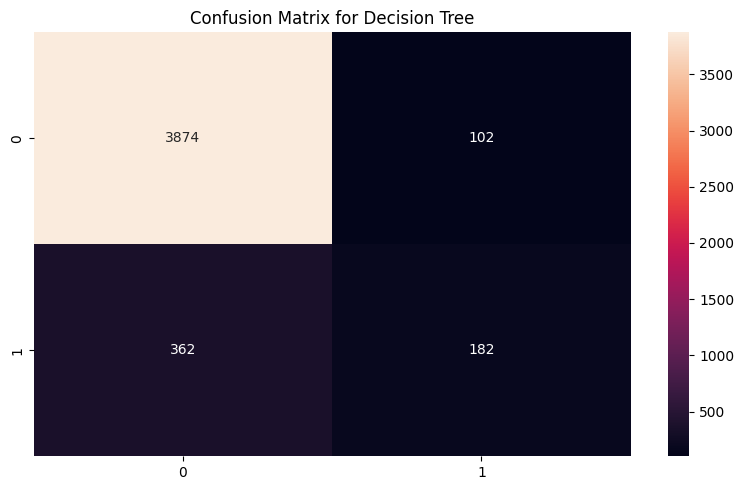

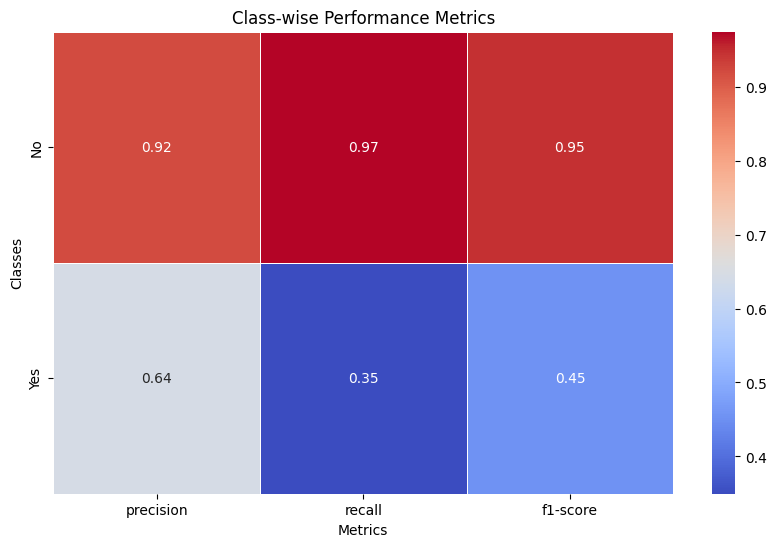

In [602]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# 7. Visualize the output
# 7.1 classification report
DT_classification_report=classification_report(y_test, DT_y_pred)
print(DT_classification_report)

# 7.2 Confusion matrix with seaborn heatmap
DT_conf_matrix=confusion_matrix(y_test, DT_y_pred)
# Seaborn heatmap
plt.figure(figsize=(8,5))
sns.heatmap(DT_conf_matrix, annot=True, fmt="d")
plt.title('Confusion Matrix for Decision Tree')
plt.tight_layout()
plt.savefig("DT_confusion_matrix.png")

# 7.3 Visualize classification report better: Class-wise Performance Metrics
DT_classification_report_2 = classification_report(y_test, DT_y_pred, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
class_metrics = {metric: [test_report[class_name][metric] for class_name in ['0','1']] for metric in metrics}

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data=pd.DataFrame(class_metrics, index=['No','Yes']), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Class-wise Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.savefig("DT_performance_metrics.png")
plt.show()

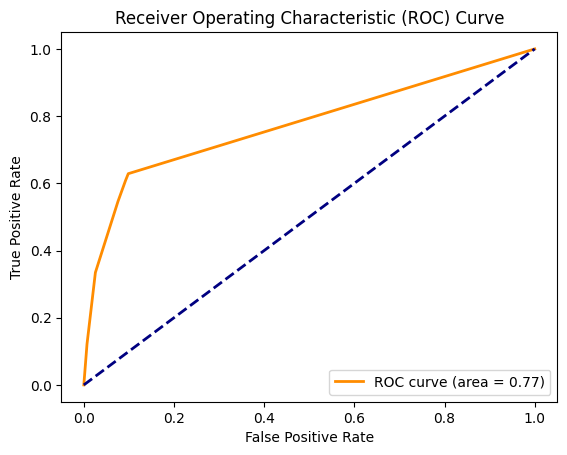

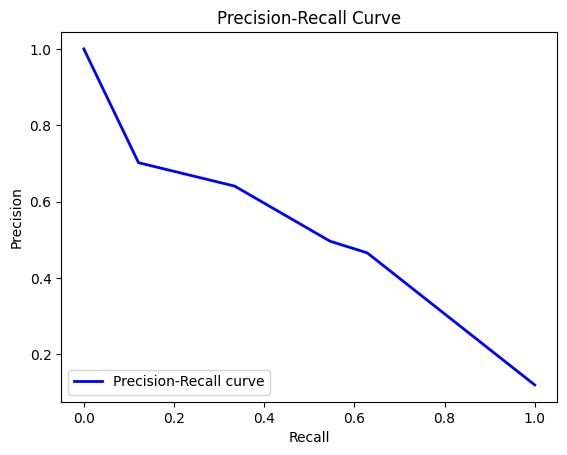

In [603]:
# More visualization
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# NOTE: only choose 1 of the following 2 methods:

# manual hyperparameter tuning
# DT_y_scores = DT_best_model.predict_proba(DT_X_test)[:, 1]

# automate hyperparameter tuning (pipeline)
DT_y_scores=DT_pipeline.predict_proba(X_test)[:, 1]


# 7.4 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, DT_y_scores)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig("DT_roc_curve.png")

# 7.5 Precision-Recall Curve (Keep it for now, can be deleted)
precision, recall, thresholds = precision_recall_curve(y_test, DT_y_scores)
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.savefig("DT_precision_recall_curve.png")
plt.show()

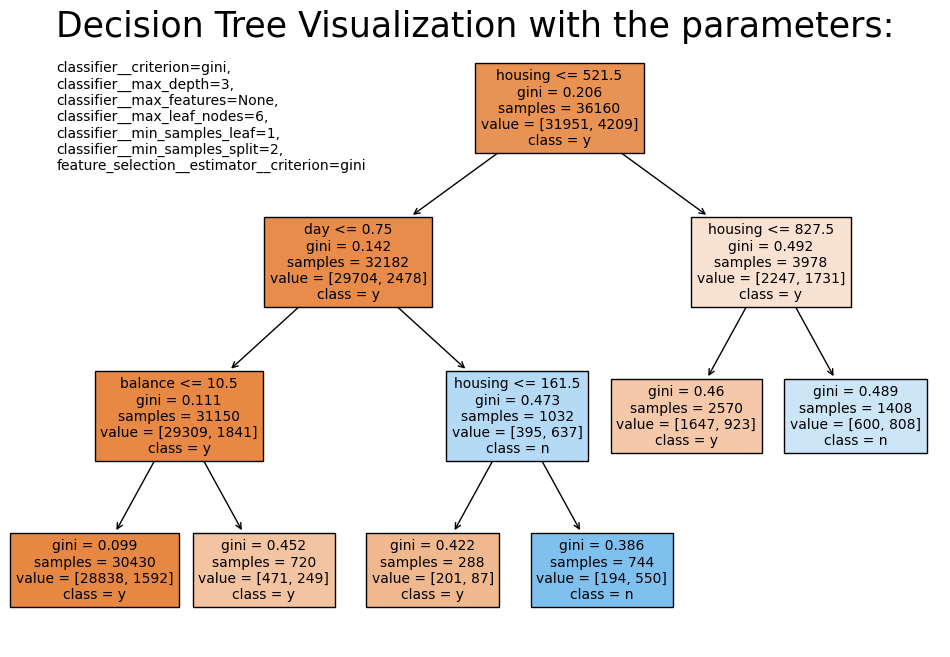

In [637]:
# 7.6 Visualize the decision tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# convert hyperparameter values in a string (only works in both manual and automatic tuning)
# DT_param_str = ', '.join([f"{key}={val}" for key, val in DT_best_params.items()])

DT_param_str = ',\n'.join([f"{key}={val}" if index % 2 == 0 else f"{key}={val}" for index, (key, val) in enumerate(DT_best_params.items())])



# Visualize the decision tree
plt.figure(figsize=(12, 8))
# manual hyperparmeter 
# plot_tree(DT_best_model, feature_names=DT_X_train.columns, class_names=['y', 'n'], filled=True)

# automated hyperparameter
DT_pipeline_classifier = DT_pipeline.named_steps['classifier']
plot_tree(DT_pipeline_classifier, feature_names=DT_X_train.columns, class_names=['y', 'n'], filled=True)

plt.title("Decision Tree Visualization with the parameters:\n\n", fontsize=25, y=0.85)
plt.text(x=0.05, y=0.775, s=DT_param_str, fontsize=10)
plt.savefig("DT_visualizations.png")
plt.show()
